# Signal System for Systematic Trading
### A Trading-Engineering Perspective for Data Scientists


Please note that these setups are presented for educational purposes only and do not constitutes professional and/or financial advice

---

**Goal:** Two production signal engines || **deterministic feature transforms** || on price data.

| System | File | Core Idea |
|---|---|---|
| **RS** | `Reversal Signals` | Sequential counting (9/13-bar) + price-flip confirmation |
| **EMMS** | `Estimated Manipulation Movement Signal` | Volatility x volume anomaly at structural liquidity levels |

**Stack:** NumPy-only (no pandas), Price Action only (No Indicator ). Data from MetaTrader 5 Terminal, broadcasts via Socket.IO.

In [1]:
import numpy as np
from dataclasses import dataclass
from typing import Dict
import json
from datetime import datetime
import matplotlib.pyplot as plt

np.set_printoptions(precision=5, suppress=True)

# Guard against accidentally creating figures too large for notebook rendering.
def safe_subplots(*args, figsize=(10, 6), max_size=(20, 20), dpi=100, **kwargs):
    w, h = figsize
    max_w, max_h = max_size
    w = float(np.clip(w, 1, max_w))
    h = float(np.clip(h, 1, max_h))
    return plt.subplots(*args, figsize=(w, h), dpi=dpi, **kwargs)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100

print(f'NumPy {np.__version__}')

NumPy 1.26.4


---
# Part 1 — Architecture Overview

```
Real-time OHLCV -> Signal Engines (numpy) -> Socket.IO Broadcast
  6 symbols x 6 TFs       ReversalSignals ---  EMMS ---       -> Clients
```

**Symbols:** EURUSD, GBPUSD, USDJPY, XAUUSD, AUDUSD, USDCAD

**Timeframes:** M5, M15, M30, H1, H4, D1

**Update interval:** 1 second

**Signal payload:** entry price, direction, target, risk, confidence, phase_count, setup_details ( this was first seen in LuxAlgo and AlgoPoint a trading indicator builder some years ago)

---
# Part 2 — Reversal Signals: Feature Taxonomy

Three signal types with increasing confidence:

| Signal | Trigger | Confidence | Interpretation |
|---|---|---|---|
| **Momentum** | 9-bar count + price flip | 50–70% | Early reversal hypothesis |
| **Exhaustion** | 13-bar count complete | ~80% | Trend saturation |
| **Qualified** | Momentum → Exhaustion → flip | ~90% | Sequential dependency model |

A **deterministic transformations of price** — Price action engineered features, not indicators.

---
## 2.1 Feature-Based Decomposition

| Feature Family | What It Computes | Framing |
|---|---|---|
| **Momentum** (sequential counting) | 9/13-bar TD Sequential-style counts | Sequential pattern encoding — discrete state machine on price relatives |
| **Adaptive Smoothing** | Running min/max within active count windows | Noise reduction — tracks structural extrema |
| **Convergence / Divergence** | Risk vs. target from mirror of extrema | Regime termination signal — symmetric projection from structural anchors |

---
## 2.2 Action Features — The Key Edge

| Trading Concept | Code Implementation | Data Science Equivalent |
|---|---|---|
| Momentum count | `close[i] < close[i-4]` → increment | **Sequential pattern encoding** |
| Exhaustion | 13-bar count after 9-bar completion | **Regime termination signal** |
| Price flip | `close[i] > close[i-4]` after bearish count | **State transition** |
| Support/Resistance | Running min/max over count window | **Local extrema / constraints** |

Every feature is a *deterministic function* of raw OHLCV. No stochastic optimization, no overfitting risk.

In [2]:
def generate_synthetic_ohlcv(n: int = 500, seed: int = 42) -> Dict[str, np.ndarray]:
    rng = np.random.default_rng(seed)
    close = 1.1000 + np.cumsum(rng.standard_normal(n) * 0.0008)
    high = close + np.abs(rng.standard_normal(n) * 0.0004)
    low  = close - np.abs(rng.standard_normal(n) * 0.0004)
    open_ = close + rng.standard_normal(n) * 0.0002
    volume = (1000 + rng.exponential(500, n)).astype(float)
    return dict(open=open_, high=high, low=low, close=close, volume=volume)

synth = generate_synthetic_ohlcv(500)
print(f'Generated {synth["close"].shape[0]} bars')
print(f'Close range: {synth["close"].min():.5f} - {synth["close"].max():.5f}')

Generated 500 bars
Close range: 1.08741 - 1.10438


---
## 2.3 Momentum Phase — Sequential Pattern Encoding

The core comparison: `con_i = 1[close_i < close_{i-4}]`

- If True: bullish count increments (up to 9), bearish resets
- If False: bearish count increments, bullish resets
- At count = 9, the counter resets

This is a **finite-state machine** with states {0, 1, ..., 9} and two parallel tracks (bullish / bearish).

In [3]:
def momentum_phase(
    o: np.ndarray, h: np.ndarray, l: np.ndarray, c: np.ndarray
) -> Dict[str, np.ndarray]:
    n = c.size
    bSC = np.zeros(n, dtype=int); sSC = np.zeros(n, dtype=int)
    bSR = np.zeros(n); sSS = np.zeros(n)
    bSD = np.zeros(n); sSD = np.zeros(n)
    bSH = np.zeros(n); bSL = np.zeros(n)
    sSH = np.zeros(n); sSL = np.zeros(n)

    for i in range(4, n):
        con = c[i] < c[i - 4]
        if con:
            bSC[i] = 1 if bSC[i-1] == 9 else bSC[i-1] + 1
            sSC[i] = 0
        else:
            sSC[i] = 1 if sSC[i-1] == 9 else sSC[i-1] + 1
            bSC[i] = 0

        if bSC[i] == 1: bSL[i] = l[i]
        if bSC[i] > 0:
            bSL[i] = min(bSL[i-1], l[i]) if bSL[i-1] > 0 else l[i]
            if l[i] == bSL[i]: bSH[i] = h[i]
            if bSC[i] == 9:
                bSD[i] = 2 * bSL[i] - bSH[i]
            else:
                bSD[i] = 0 if c[i] < bSD[i-1] or sSC[i] == 9 else bSD[i-1]
            bC8 = bSC[i-1] == 8 and sSC[i] == 1
            if bSC[i] == 9 or bC8:
                bSR[i] = np.max(h[max(0, i-8):i+1])
        else:
            bSR[i] = 0 if c[i] > bSR[i-1] else bSR[i-1]

        if sSC[i] == 1: sSH[i] = h[i]
        if sSC[i] > 0:
            sSH[i] = max(sSH[i-1], h[i]) if sSH[i-1] > 0 else h[i]
            if h[i] == sSH[i]: sSL[i] = l[i]
            if sSC[i] == 9:
                sSD[i] = 2 * sSH[i] - sSL[i]
            else:
                sSD[i] = 0 if c[i] > sSD[i-1] or bSC[i] == 9 else sSD[i-1]
            sC8 = sSC[i-1] == 8 and bSC[i] == 1
            if sSC[i] == 9 or sC8:
                sSS[i] = np.min(l[max(0, i-8):i+1])
        else:
            sSS[i] = 0 if c[i] < sSS[i-1] else sSS[i-1]

    return dict(bSC=bSC, sSC=sSC, bSR=bSR, sSS=sSS,
                bSD=bSD, sSD=sSD, bSH=bSH, bSL=bSL, sSH=sSH, sSL=sSL)

mom = momentum_phase(synth['open'], synth['high'], synth['low'], synth['close'])
b9 = np.flatnonzero(mom['bSC'] == 9)
s9 = np.flatnonzero(mom['sSC'] == 9)
print(f'Bullish 9-count completions: {b9.size}')
print(f'Bearish  9-count completions: {s9.size}')

Bullish 9-count completions: 6
Bearish  9-count completions: 5


### State Machine Visualization

Two parallel (bullish / bearish) with mutual exclusion. State 9 is a **terminal emission state**.

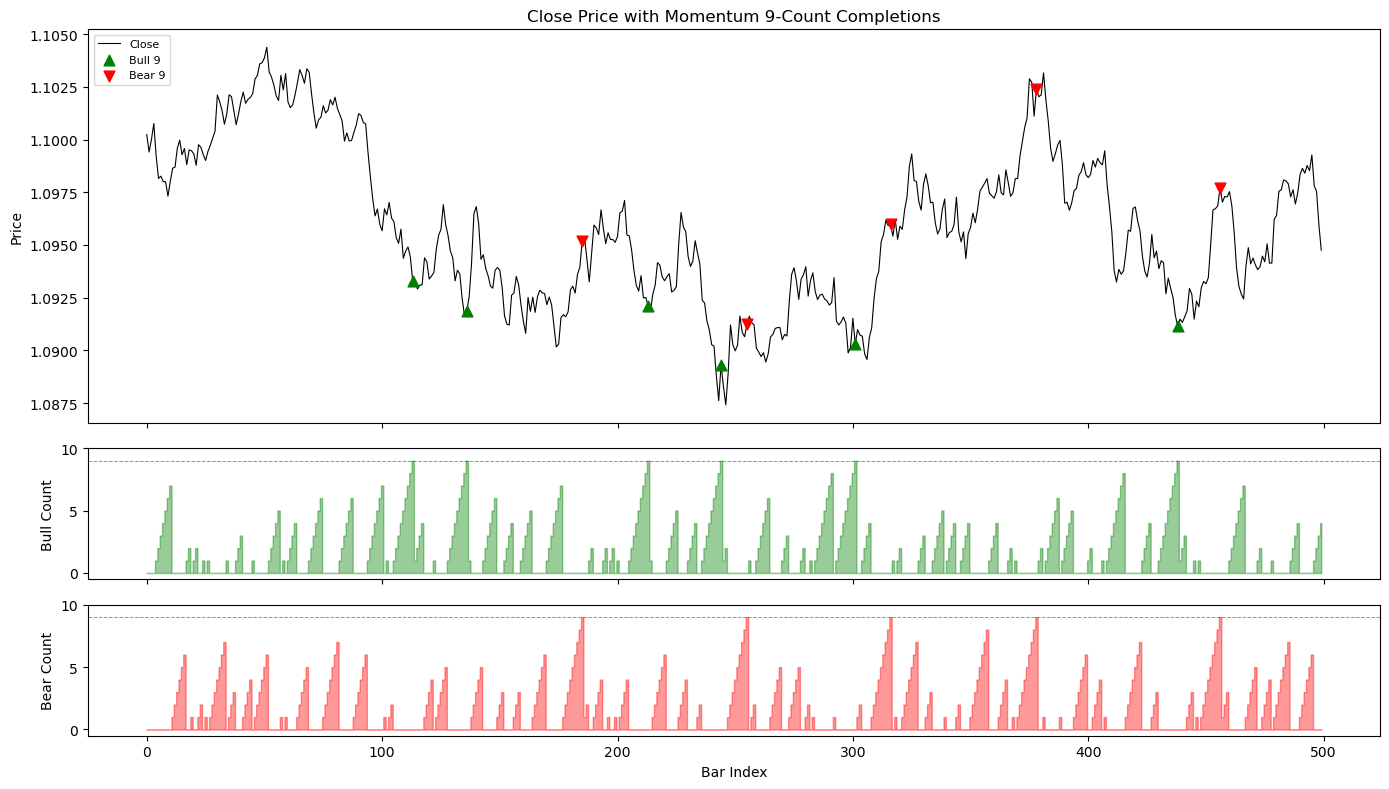

In [4]:
fig, axes = safe_subplots(3, 1, figsize=(14, 8), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1, 1]})
x = np.arange(synth['close'].size)

axes[0].plot(x, synth['close'], color='black', linewidth=0.8, label='Close')
axes[0].scatter(b9, synth['close'][b9], marker='^', c='green', s=60, zorder=5, label='Bull 9')
axes[0].scatter(s9, synth['close'][s9], marker='v', c='red', s=60, zorder=5, label='Bear 9')
axes[0].set_ylabel('Price'); axes[0].legend(loc='upper left', fontsize=8)
axes[0].set_title('Close Price with Momentum 9-Count Completions')

axes[1].fill_between(x, mom['bSC'], step='mid', alpha=0.4, color='green')
axes[1].set_ylabel('Bull Count'); axes[1].set_ylim(-0.5, 10)
axes[1].axhline(9, color='green', linestyle='--', linewidth=0.7, alpha=0.6)

axes[2].fill_between(x, mom['sSC'], step='mid', alpha=0.4, color='red')
axes[2].set_ylabel('Bear Count'); axes[2].set_ylim(-0.5, 10)
axes[2].axhline(9, color='red', linestyle='--', linewidth=0.7, alpha=0.6)
axes[2].set_xlabel('Bar Index')

plt.tight_layout(); plt.show()

---
## 2.4 Exhaustion Phase — Regime Termination Signal

A **second-stage state machine** gated by the first:

1. **Entry:** Momentum 9-count completes + "perfect" price pattern
2. **Counting:** `close[i] <= low[i-2]` (bullish) or `close[i] >= high[i-2]` (bearish)
3. **Terminal:** Count reaches 13
4. **Guard:** If count=13 but close doesn't meet bar-8 anchor, reset to 12

This is a **gated sequential encoder** — the exhaustion counter only activates after momentum reaches terminal state.

In [5]:
def exhaustion_phase(
    o: np.ndarray, h: np.ndarray, l: np.ndarray, c: np.ndarray,
    mom: Dict[str, np.ndarray]
) -> Dict[str, np.ndarray]:
    n = c.size
    bSC, sSC = mom['bSC'], mom['sSC']
    bSR, sSS = mom['bSR'], mom['sSS']
    bCC = np.zeros(n, dtype=int); sCC = np.zeros(n, dtype=int)
    bCL = np.zeros(n); bCH = np.zeros(n)
    sCL = np.zeros(n); sCH = np.zeros(n)
    bCD = np.zeros(n); bCT = np.zeros(n)
    sCD = np.zeros(n); sCT = np.zeros(n)
    bC8 = np.zeros(n); sC8 = np.zeros(n)

    pbS = np.zeros(n, dtype=bool); psS = np.zeros(n, dtype=bool)
    for i in range(3, n):
        pbS[i] = (l[i] <= l[i-3] and l[i] <= l[i-2]) or (l[i-1] <= l[i-3] and l[i-1] <= l[i-2])
        psS[i] = (h[i] >= h[i-3] and h[i] >= h[i-2]) or (h[i-1] >= h[i-3] and h[i-1] >= h[i-2])

    sbC = False; ssC = False
    bCLt = bCHt = sCLt = sCHt = 0.0

    for i in range(2, n):
        bCC_cond = c[i] <= l[i-2]
        sCC_cond = c[i] >= h[i-2]

        if i > 0:
            if bSC[i] == 9 and bCC[i-1] == 0 and (pbS[i] or pbS[i-1]): sbC = True
            elif sSC[i] == 9 or bCC[i-1] == 13 or c[i] > bSR[i]: sbC = False
        if i > 0:
            if sSC[i] == 9 and sCC[i-1] == 0 and (psS[i] or psS[i-1]): ssC = True
            elif bSC[i] == 9 or sCC[i-1] == 13 or c[i] < sSS[i]: ssC = False

        # Bullish exhaustion
        if sbC:
            bCC[i] = 1 if bCC[i-1] == 0 else (bCC[i-1] + 1 if bCC_cond else 0)
            if not bCC_cond: bCC[i] = 0
            if bCC[i] == 13 and bCC_cond and l[i] >= bC8[i-1]: bCC[i] = 12
        else:
            bCC[i] = 0

        bC8[i] = c[i] if bCC[i] == 8 and bCC[i] != bCC[i-1] else (bC8[i-1] if i > 0 else 0.0)

        if bCC[i] == 1: bCLt = l[i]; bCHt = h[i]
        elif sbC:
            bCHt = max(bCHt, h[i]); bCLt = min(bCLt, l[i])
            if h[i] == bCHt: bCH[i] = h[i]
            if l[i] == bCLt: bCL[i] = l[i]

        if bCC[i] == 13:
            bCT[i] = 2 * bCHt - bCL[i]; bCD[i] = 2 * bCLt - bCH[i]
        else:
            bCT[i] = 0 if c[i] > bCT[i-1] or (bCD[i-1]==0 and sCC[i]==13) else bCT[i-1]
            bCD[i] = 0 if c[i] < bCD[i-1] or (bCT[i-1]==0 and sCC[i]==13) else bCD[i-1]

        # Bearish exhaustion
        if ssC:
            sCC[i] = 1 if sCC[i-1] == 0 else (sCC[i-1] + 1 if sCC_cond else 0)
            if not sCC_cond: sCC[i] = 0
            if sCC[i] == 13 and sCC_cond and h[i] <= sC8[i-1]: sCC[i] = 12
        else:
            sCC[i] = 0

        sC8[i] = c[i] if sCC[i] == 8 and sCC[i] != sCC[i-1] else (sC8[i-1] if i > 0 else 0.0)

        if sCC[i] == 1: sCLt = l[i]; sCHt = h[i]
        elif ssC:
            sCHt = max(sCHt, h[i]); sCLt = min(sCLt, l[i])
            if h[i] == sCHt: sCH[i] = h[i]
            if l[i] == sCLt: sCL[i] = l[i]

        if sCC[i] == 13:
            sCD[i] = 2 * sCHt - sCL[i]; sCT[i] = 2 * sCLt - sCH[i]
        else:
            sCD[i] = 0 if c[i] > sCD[i-1] or (sCT[i-1]==0 and bCC[i]==13) else sCD[i-1]
            sCT[i] = 0 if c[i] < sCT[i-1] or (sCD[i-1]==0 and bCC[i]==13) else sCT[i-1]

    return dict(bCC=bCC, sCC=sCC, bCL=bCL, bCH=bCH, sCL=sCL, sCH=sCH,
                bCD=bCD, bCT=bCT, sCD=sCD, sCT=sCT, bC8=bC8, sC8=sC8)

exh = exhaustion_phase(synth['open'], synth['high'], synth['low'], synth['close'], mom)
print(f'Bullish 13-count completions: {np.count_nonzero(exh["bCC"] == 13)}')
print(f'Bearish  13-count completions: {np.count_nonzero(exh["sCC"] == 13)}')

Bullish 13-count completions: 0
Bearish  13-count completions: 0


---
## 2.5 Signal Type 1 — Momentum Signal

| Attribute | Value |
|---|---|
| **Trigger** | 9-bar momentum count + price flip |
| **Confidence** | 50–70% |
| **Interpretation** | Early-stage reversal hypothesis |
| **Price flip** | `close[i] > close[i-4] AND close[i-1] < close[i-5]` (bullish) |

Data science view: A **first-order state emission** — the primary reaches terminal state 9 and a sign change confirms intent.

In [6]:
def momentum_signals(c, h, l, mom):
    n = c.size
    bSC, sSC = mom['bSC'], mom['sSC']
    bSR, sSS = mom['bSR'], mom['sSS']
    bSD, sSD = mom['bSD'], mom['sSD']
    signal = np.full(n, '', dtype='U4'); setup = np.full(n, '', dtype='U10')
    target = np.zeros(n); risk = np.zeros(n); conf = np.zeros(n)

    for i in range(5, n):
        bullish_flip = c[i] > c[i-4] and c[i-1] < c[i-5]
        bearish_flip = c[i] < c[i-4] and c[i-1] > c[i-5]
        bC8 = bSC[i-1] == 8 and sSC[i] == 1
        sC8 = sSC[i-1] == 8 and bSC[i] == 1

        if (bSC[i] == 9 or bC8) and bullish_flip:
            signal[i] = 'BUY'; setup[i] = 'MOMENTUM'
            target[i] = bSR[i] if bSR[i] > 0 else h[i] * 1.01
            risk[i] = bSD[i] if bSD[i] > 0 else l[i]
            conf[i] = 0.7 if bSC[i] == 9 else 0.5

        if (sSC[i] == 9 or sC8) and bearish_flip:
            signal[i] = 'SELL'; setup[i] = 'MOMENTUM'
            target[i] = sSS[i] if sSS[i] > 0 else l[i] * 0.99
            risk[i] = sSD[i] if sSD[i] > 0 else h[i]
            conf[i] = 0.7 if sSC[i] == 9 else 0.5

    return dict(signal=signal, setup=setup, target=target, risk=risk, confidence=conf)

mom_sig = momentum_signals(synth['close'], synth['high'], synth['low'], mom)
print(f'Momentum BUY  signals: {(mom_sig["signal"]=="BUY").sum()}')
print(f'Momentum SELL signals: {(mom_sig["signal"]=="SELL").sum()}')

Momentum BUY  signals: 2
Momentum SELL signals: 1


---
## 2.6 Signal Type 2 — Exhaustion Signal

| Attribute | Value |
|---|---|
| **Trigger** | 13-bar exhaustion count + price flip |
| **Confidence** | ~80% |
| **Interpretation** | Late-stage trend saturation |

Data science view: A **second-order state emission** — requires the first (momentum 9) to have completed, then a secondary counter reaches 13. This models **sequential dependency between regimes**.

In [7]:
def exhaustion_signals(c, h, l, exh):
    n = c.size
    bCC, sCC = exh['bCC'], exh['sCC']
    bCT, sCT = exh['bCT'], exh['sCT']
    bCD, sCD = exh['bCD'], exh['sCD']
    signal = np.full(n, '', dtype='U4'); setup = np.full(n, '', dtype='U10')
    target = np.zeros(n); risk = np.zeros(n); conf = np.zeros(n)

    for i in range(5, n):
        bullish_flip = c[i] > c[i-4] and c[i-1] < c[i-5]
        bearish_flip = c[i] < c[i-4] and c[i-1] > c[i-5]

        if bCC[i] == 13 and bullish_flip:
            signal[i] = 'BUY'; setup[i] = 'EXHAUSTION'
            target[i] = bCT[i] if bCT[i] > 0 else h[i] * 1.02
            risk[i] = bCD[i] if bCD[i] > 0 else l[i]; conf[i] = 0.8

        if sCC[i] == 13 and bearish_flip:
            signal[i] = 'SELL'; setup[i] = 'EXHAUSTION'
            target[i] = sCT[i] if sCT[i] > 0 else l[i] * 0.98
            risk[i] = sCD[i] if sCD[i] > 0 else h[i]; conf[i] = 0.8

    return dict(signal=signal, setup=setup, target=target, risk=risk, confidence=conf)

exh_sig = exhaustion_signals(synth['close'], synth['high'], synth['low'], exh)
print(f'Exhaustion BUY  signals: {(exh_sig["signal"]=="BUY").sum()}')
print(f'Exhaustion SELL signals: {(exh_sig["signal"]=="SELL").sum()}')

Exhaustion BUY  signals: 0
Exhaustion SELL signals: 0


---
## 2.7 Signal Type 3 — Qualified Signal (Highest Confidence)

| Attribute | Value |
|---|---|
| **Trigger** | Momentum 9 → Exhaustion 13 → Price flip |
| **Confidence** | ~90% |
| **Interpretation** | Sequential dependency model (state-transition validation) |

The qualified signal requires **temporal ordering**:
1. A momentum regime started (9-count)
2. An exhaustion regime completed (13-count)
3. A *new* momentum regime emerged (second 9-count)
4. Price action confirmed direction

This is a **Markov-chain dependency** — all three regimes must fire in sequence.

In [8]:
def qualified_signals(c, h, l, mom, exh):
    n = c.size
    bSC, sSC = mom['bSC'], mom['sSC']
    bSR, sSS = mom['bSR'], mom['sSS']
    bSD, sSD = mom['bSD'], mom['sSD']
    bCC, sCC = exh['bCC'], exh['sCC']
    bCT, sCT = exh['bCT'], exh['sCT']
    bCD, sCD = exh['bCD'], exh['sCD']
    signal = np.full(n, '', dtype='U4'); setup = np.full(n, '', dtype='U10')
    target = np.zeros(n); risk = np.zeros(n); conf = np.zeros(n)
    lookback = 50

    for i in range(14, n):
        bullish_flip = c[i] > c[i-4] and c[i-1] < c[i-5]
        bearish_flip = c[i] < c[i-4] and c[i-1] > c[i-5]

        bBl9 = bBp9 = bB13 = None
        for j in range(i-1, max(0, i-lookback), -1):
            if bSC[j] == 9 and bBl9 is None: bBl9 = j
            elif bSC[j] == 9 and bBp9 is None: bBp9 = j; break
        for j in range(i-1, max(0, i-lookback), -1):
            if bCC[j] == 13 and bB13 is None: bB13 = j; break
        bQC = bBl9 is not None and bB13 is not None and bBp9 is not None and bBl9 > bB13 and bB13 > bBp9

        sBl9 = sBp9 = sB13 = None
        for j in range(i-1, max(0, i-lookback), -1):
            if sSC[j] == 9 and sBl9 is None: sBl9 = j
            elif sSC[j] == 9 and sBp9 is None: sBp9 = j; break
        for j in range(i-1, max(0, i-lookback), -1):
            if sCC[j] == 13 and sB13 is None: sB13 = j; break
        sQC = sBl9 is not None and sB13 is not None and sBp9 is not None and sBl9 > sB13 and sB13 > sBp9

        if bSC[i] == 9 and bQC and bullish_flip:
            signal[i] = 'BUY'; setup[i] = 'QUALIFIED'
            target[i] = bCT[i] if bCT[i]>0 else (bSR[i] if bSR[i]>0 else h[i]*1.02)
            risk[i] = bCD[i] if bCD[i]>0 else (bSD[i] if bSD[i]>0 else l[i])
            conf[i] = 0.9

        if sSC[i] == 9 and sQC and bearish_flip:
            signal[i] = 'SELL'; setup[i] = 'QUALIFIED'
            target[i] = sCT[i] if sCT[i]>0 else (sSS[i] if sSS[i]>0 else l[i]*0.98)
            risk[i] = sCD[i] if sCD[i]>0 else (sSD[i] if sSD[i]>0 else h[i])
            conf[i] = 0.9

    return dict(signal=signal, setup=setup, target=target, risk=risk, confidence=conf)

q_sig = qualified_signals(synth['close'], synth['high'], synth['low'], mom, exh)
print(f'Qualified BUY  signals: {(q_sig["signal"]=="BUY").sum()}')
print(f'Qualified SELL signals: {(q_sig["signal"]=="SELL").sum()}')

Qualified BUY  signals: 0
Qualified SELL signals: 0


---
## 2.8 Multi-Timeframe Fusion

Signals computed independently across 6 timeframes. Agreement = higher confidence.

| Timeframes Agree | Boost |
|---|---|
| 1 | Base (50–90%) |
| 2 | +5% |
| 3+ | +10% |
| 4+ | +15% |

This is **ensemble voting** — multiple independent classifiers on different granularity.

In [9]:
def multi_timeframe_fusion(timeframe_signals):
    buy_count = sell_count = 0
    weighted_conf = total_weight = 0.0
    tf_weights = {'M5': 0.5, 'M15': 0.7, 'M30': 0.8, 'H1': 1.0, 'H4': 1.2, 'D1': 1.5}
    breakdown = {}
    for tf_name, sig in timeframe_signals.items():
        last = len(sig['signal']) - 1
        direction = str(sig['signal'][last])
        cnf = float(sig['confidence'][last])
        weight = tf_weights.get(tf_name, 1.0)
        breakdown[tf_name] = dict(direction=direction, confidence=cnf, weight=weight)
        if direction == 'BUY': buy_count += 1; weighted_conf += cnf * weight
        elif direction == 'SELL': sell_count += 1; weighted_conf += cnf * weight
        total_weight += weight if direction in ('BUY','SELL') else 0

    fused_dir = 'BUY' if buy_count > sell_count else ('SELL' if sell_count > buy_count else 'NONE')
    agreement = max(buy_count, sell_count)
    base_conf = weighted_conf / total_weight if total_weight > 0 else 0
    boost = {1: 0.0, 2: 0.05, 3: 0.10, 4: 0.15, 5: 0.15, 6: 0.15}
    fused_conf = min(base_conf + boost.get(agreement, 0.15), 0.99)
    return dict(direction=fused_dir, confidence=round(fused_conf, 4),
                agreement=agreement, breakdown=breakdown)

# Demo
rng = np.random.default_rng(99)
demo_tfs = {}
for tf in ['M5','M15','M30','H1','H4','D1']:
    n_bars = rng.integers(200, 600)
    s = np.full(n_bars, '', dtype='U4'); s[-1] = rng.choice(['BUY','SELL',''], p=[0.4,0.4,0.2])
    cnf = np.zeros(n_bars); cnf[-1] = rng.uniform(0.5, 0.9)
    demo_tfs[tf] = dict(signal=s, confidence=cnf)

fused = multi_timeframe_fusion(demo_tfs)
print(f'Fused direction:  {fused["direction"]}')
print(f'Fused confidence: {fused["confidence"]:.2%}')
print(f'Agreement:         {fused["agreement"]}/6 timeframes')
for tf, info in fused['breakdown'].items():
    if info['direction']: print(f'  {tf:>3}: {info["direction"]:4}  conf={info["confidence"]:.2f}  w={info["weight"]:.1f}')

Fused direction:  BUY
Fused confidence: 76.69%
Agreement:         3/6 timeframes
   M5: SELL  conf=0.70  w=0.5
  M30: BUY   conf=0.72  w=0.8
   H1: SELL  conf=0.74  w=1.0
   H4: BUY   conf=0.62  w=1.2
   D1: BUY   conf=0.61  w=1.5


---
## 2.9 Reversal Signals — Signal Data Schema

Each signal carries: symbol, timeframe, timestamp, signal_type, direction, price, target, risk, confidence, phase_count, setup_details.

In [10]:
def build_signal_payload(symbol, timeframe, signal_type, direction,
                         price, target, risk, confidence, phase_count, **details):
    return {
        'symbol': symbol, 'timeframe': timeframe,
        'timestamp': datetime.utcnow().isoformat() + 'Z',
        'signal_type': signal_type, 'direction': direction,
        'price': round(price, 5), 'target': round(target, 5),
        'risk': round(risk, 5), 'confidence': round(confidence, 2),
        'phase_count': phase_count, 'setup_details': details,
    }

examples = [
    build_signal_payload('EURUSD','H1','MOMENTUM','BUY', 1.08520, 1.09000, 1.08200, 0.70, 9,
                         flip='bullish', resistance=1.09000),
    build_signal_payload('GBPUSD','H4','EXHAUSTION','SELL', 1.27300, 1.26500, 1.27600, 0.80, 13,
                         flip='bearish', support=1.26500),
    build_signal_payload('XAUUSD','D1','QUALIFIED','BUY', 2340.50, 2400.00, 2310.00, 0.90, 9,
                         flip='bullish', resistance=2400.00, exhaustion_count=13),
]
for ex in examples:
    print(json.dumps(ex, indent=2)); print()

{
  "symbol": "EURUSD",
  "timeframe": "H1",
  "timestamp": "2026-04-30T18:24:32.439926Z",
  "signal_type": "MOMENTUM",
  "direction": "BUY",
  "price": 1.0852,
  "target": 1.09,
  "risk": 1.082,
  "confidence": 0.7,
  "phase_count": 9,
  "setup_details": {
    "flip": "bullish",
    "resistance": 1.09
  }
}

{
  "symbol": "GBPUSD",
  "timeframe": "H4",
  "timestamp": "2026-04-30T18:24:32.439926Z",
  "signal_type": "EXHAUSTION",
  "direction": "SELL",
  "price": 1.273,
  "target": 1.265,
  "risk": 1.276,
  "confidence": 0.8,
  "phase_count": 13,
  "setup_details": {
    "flip": "bearish",
    "support": 1.265
  }
}

{
  "symbol": "XAUUSD",
  "timeframe": "D1",
  "timestamp": "2026-04-30T18:24:32.439926Z",
  "signal_type": "QUALIFIED",
  "direction": "BUY",
  "price": 2340.5,
  "target": 2400.0,
  "risk": 2310.0,
  "confidence": 0.9,
  "phase_count": 9,
  "setup_details": {
    "flip": "bullish",
    "resistance": 2400.0,
    "exhaustion_count": 13
  }
}



C:\Users\babat\AppData\Local\Temp\ipykernel_2548\2893749906.py:5: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'timestamp': datetime.utcnow().isoformat() + 'Z',


---
# Part 3 — Estimated Manipulation Movement Signal (EMMS)

EMMS detects **institutional manipulation** by identifying candles that simultaneously exhibit:

1. **Volatility anomaly** — candle range > ATR x multiplier
2. **Volume anomaly** — volume > mean x multiplier
3. **Liquidity sweep** — price pierces a structural pivot but closes back inside
4. **Absorption pattern** — candle body opposes the sweep direction

---
## 3.1 EMMS Feature Decomposition

| Feature Family | Computation | Data Science Framing |
|---|---|---|
| ATR-based volatility filter | `range > ATR(21) x 1.9` | Adaptive outlier detection |
| Volume filter | `volume > SMA(21) x 1.618` | Relative volume anomaly (golden ratio) |
| Structural pivots | `pivot_high(h, 55, 55)` | Local extrema with left/right confirmation |
| Liquidity sweep | `low < prev_pivot_low AND close > prev_pivot_low` | Boundary violation + re-entry |
| Absorption | Red candle + vol spike + close_position > 0.5 | Opposing pressure absorbs the sweep |

---
## 3.2 EMMS — Trading to Data Science Translation

| Trading Concept | Implementation | Data Science Equivalent |
|---|---|---|
| Volatility spike | `candle_range > ATR x 1.9` | Adaptive outlier detection |
| Volume spike | `volume > SMA(volume, 21) x 1.618` | Relative volume anomaly |
| Anomaly candle | volatility_spike AND volume_spike | Conjunction of independent detectors |
| Liquidity sweep | `low < pivot_low AND close > pivot_low` | Boundary violation + re-entry |
| Bullish absorption | red + vol_spike + close_pos > 0.5 | Opposing absorption |

In [ ]:
def shift_1(arr):
    out = np.empty_like(arr, dtype=float); out[0] = np.nan; out[1:] = arr[:-1]
    return out

def rolling_mean(arr, period):
    out = np.full(arr.shape, np.nan, dtype=float)
    if period <= 0 or period > arr.size: return out
    csum = np.cumsum(np.insert(arr.astype(float), 0, 0.0))
    out[period-1:] = (csum[period:] - csum[:-period]) / period
    return out

def wilder_rma(arr, period):
    out = np.full(arr.shape, np.nan, dtype=float)
    if period <= 0 or period > arr.size: return out
    out[period-1] = np.mean(arr[:period])
    alpha = 1.0 / period
    for i in range(period, arr.size): out[i] = out[i-1] + alpha * (arr[i] - out[i-1])
    return out

def true_range(high, low, close):
    prev_close = shift_1(close)
    return np.nanmax(np.stack((high-low, np.abs(high-prev_close), np.abs(low-prev_close)), axis=0), axis=0)

def atr(high, low, close, period):
    return wilder_rma(true_range(high, low, close), period)

def forward_fill_nan(arr):
    out = arr.copy().astype(float)
    valid = ~np.isnan(out)
    if not np.any(valid): return out
    idx = np.where(valid, np.arange(out.size), 0)
    np.maximum.accumulate(idx, out=idx)
    out = out[idx]
    out[:np.argmax(valid)] = np.nan
    return out

def pivot_high(series, left, right):
    out = np.full(series.shape, np.nan, dtype=float)
    for i in range(left, series.size - right):
        window = series[i-left:i+right+1]
        if np.isclose(series[i], np.nanmax(window), rtol=0.0, atol=0.0): out[i] = series[i]
    return out

def pivot_low(series, left, right):
    out = np.full(series.shape, np.nan, dtype=float)
    for i in range(left, series.size - right):
        window = series[i-left:i+right+1]
        if np.isclose(series[i], np.nanmin(window), rtol=0.0, atol=0.0): out[i] = series[i]
    return out

print('EMMS utility functions loaded.')

In [ ]:
@dataclass(frozen=True)
class EMMSConfig:
    atm_lookback: int = 21
    volatility_multiplier: float = 1.9
    volume_multiplier: float = 1.618
    lbm_pivot_lookback: int = 55
    use_eam_confirmation: bool = False
    label_atr_period: int = 30

def compute_emms(data, cfg=None):
    cfg = cfg or EMMSConfig()
    o = data['open'].astype(float, copy=False)
    h = data['high'].astype(float, copy=False)
    l = data['low'].astype(float, copy=False)
    c = data['close'].astype(float, copy=False)
    v = data['volume'].astype(float, copy=False)

    atr_atm = atr(h, l, c, cfg.atm_lookback)
    avg_volume = rolling_mean(v, cfg.atm_lookback)
    candle_range = h - l

    is_vol_spike = candle_range > (atr_atm * cfg.volatility_multiplier)
    is_vol_spike_v = v > (avg_volume * cfg.volume_multiplier)
    is_anomaly = is_vol_spike & is_vol_spike_v

    lb = cfg.lbm_pivot_lookback
    piv_h = pivot_high(h, lb, lb); piv_l = pivot_low(l, lb, lb)
    last_h = forward_fill_nan(piv_h); last_l = forward_fill_nan(piv_l)
    prev_h = shift_1(last_h); prev_l = shift_1(last_l)

    safe_range = candle_range.copy(); safe_range[safe_range == 0.0] = np.nan
    close_pos = (c - l) / safe_range

    is_red = c < o; is_green = c > o
    is_bull_abs = is_red & is_vol_spike_v & (close_pos > 0.5)
    is_bear_abs = is_green & is_vol_spike_v & (close_pos < 0.5)

    long_gate = is_bull_abs if cfg.use_eam_confirmation else np.ones_like(is_anomaly, dtype=bool)
    short_gate = is_bear_abs if cfg.use_eam_confirmation else np.ones_like(is_anomaly, dtype=bool)

    long_sig = is_anomaly & is_red & (l < prev_l) & (c > prev_l) & long_gate
    short_sig = is_anomaly & is_green & (h > prev_h) & (c < prev_h) & short_gate

    label_atr = atr(h, l, c, cfg.label_atr_period)
    return dict(atr_atm=atr_atm, avg_volume=avg_volume,
               is_volatility_spike=is_vol_spike, is_volume_spike=is_vol_spike_v,
               is_anomaly_candle=is_anomaly, pivot_high_price=piv_h, pivot_low_price=piv_l,
               last_pivot_high=last_h, last_pivot_low=last_l,
               is_bullish_absorption=is_bull_abs, is_bearish_absorption=is_bear_abs,
               long_signal=long_sig, short_signal=short_sig,
               y1=l-label_atr, y2=h+label_atr)

emms = compute_emms(synth, EMMSConfig())
print(f'Anomaly candles:     {np.count_nonzero(emms["is_anomaly_candle"])}')
print(f'EMMS long  signals:  {np.count_nonzero(emms["long_signal"])}')
print(f'EMMS short signals:  {np.count_nonzero(emms["short_signal"])}')

In [ ]:
fig, axes = safe_subplots(5, 1, figsize=(14, 12), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1, 1, 1, 1]})
x = np.arange(synth['close'].size)

axes[0].plot(x, synth['close'], color='black', linewidth=0.8)
ph_mask = ~np.isnan(emms['pivot_high_price'])
pl_mask = ~np.isnan(emms['pivot_low_price'])
axes[0].scatter(x[ph_mask], emms['pivot_high_price'][ph_mask], marker='v', c='red', s=30, zorder=5, label='Pivot High')
axes[0].scatter(x[pl_mask], emms['pivot_low_price'][pl_mask], marker='^', c='green', s=30, zorder=5, label='Pivot Low')
long_idx = np.flatnonzero(emms['long_signal'])
short_idx = np.flatnonzero(emms['short_signal'])
if len(long_idx) > 0:
    axes[0].scatter(long_idx, synth['close'][long_idx], marker='^', c='lime', edgecolors='green', s=80, zorder=6, label='Long')
if len(short_idx) > 0:
    axes[0].scatter(short_idx, synth['close'][short_idx], marker='v', c='salmon', edgecolors='red', s=80, zorder=6, label='Short')
axes[0].set_ylabel('Price'); axes[0].legend(loc='upper left', fontsize=7)
axes[0].set_title('EMMS: Price with Pivots & Signals')

axes[1].plot(x, emms['atr_atm'], color='purple', linewidth=0.7); axes[1].set_ylabel('ATR(21)')
axes[2].bar(x, synth['volume'], width=1.0, color='steelblue', alpha=0.6)
axes[2].plot(x, emms['avg_volume'], color='orange', linewidth=0.8, label='Avg Vol')
axes[2].set_ylabel('Volume')

anom = emms['is_anomaly_candle'].astype(float)
axes[3].fill_between(x, anom, step='mid', alpha=0.5, color='red'); axes[3].set_ylabel('Anomaly')

cp = (synth['close'] - synth['low']) / np.maximum(synth['high'] - synth['low'], 1e-10)
axes[4].plot(x, cp, color='teal', linewidth=0.5)
axes[4].axhline(0.5, color='gray', linestyle='--', linewidth=0.5)
axes[4].set_ylabel('Close Pos'); axes[4].set_xlabel('Bar Index')

plt.tight_layout(); plt.show()

---
## 3.3 EMMS Signal Types & Target/Risk

| Signal | Direction | Conditions | Confidence Framework |
|---|---|---|---|
| **Long (BUY)** | Bullish reversal | Anomaly + red candle + sweep below pivot + close above pivot | High when absorption confirms |
| **Short (SELL)** | Bearish reversal | Anomaly + green candle + sweep above pivot + close below pivot | High when absorption confirms |

**Target/Risk labels** (ATR-scaled, unlike Reversal's mirror-derived levels):
- Long target (y2): `high + ATR(30)`
- Long risk (y1): `low - ATR(30)`
- Short target (y1): `low - ATR(30)`
- Short risk (y2): `high + ATR(30)`

In [ ]:
def build_emms_payload(symbol, timeframe, direction, price, target, risk,
                       volatility_spike, volume_spike, absorption, liquidity_sweep):
    score = sum([volatility_spike, volume_spike, absorption, liquidity_sweep]) * 0.25
    return dict(symbol=symbol, timeframe=timeframe,
                timestamp=datetime.utcnow().isoformat()+'Z',
                signal_type='EMMS', direction=direction,
                price=round(price,5), target=round(target,5), risk=round(risk,5),
                confidence=round(score,2),
                features=dict(volatility_spike=volatility_spike, volume_spike=volume_spike,
                              absorption=absorption, liquidity_sweep=liquidity_sweep))

for ex in [
    build_emms_payload('EURUSD','H1','BUY', 1.08520, 1.08520+0.0035, 1.08520-0.0035, True, True, True, True),
    build_emms_payload('XAUUSD','H4','SELL', 2340.50, 2340.50-28, 2340.50+28, True, True, False, True),
]:
    print(json.dumps(ex, indent=2)); print()

---
# Part 4 — MT5 Integration & Real-Time Architecture

**6 symbols x 6 timeframes = 36 concurrent OHLCV feeds**, updated every 1 second.

The `RealTimeDataManager` orchestrates: fetch latest bars, diff against cache, append, trim to 1000, recompute signals, broadcast if new signal.

## Socket.IO Broadcast

| Event | Direction | Payload |
|---|---|---|
| `connect` | Client → Server | Connection established |
| `get_signals` | Client → Server | `{symbol, timeframe}` request |
| `signals_response` | Server → Client | Latest signal |
| `get_all_data` | Client → Server | Request all symbols x timeframes |
| `all_data_response` | Server → Client | Full signal matrix |
| `new_signal` | Server → Client (push) | Real-time signal emission |

In [ ]:
class SimulatedDataManager:
    SYMBOLS = ['EURUSD','GBPUSD','USDJPY','XAUUSD','AUDUSD','USDCAD']
    TIMEFRAMES = ['M5','M15','M30','H1','H4','D1']

    def __init__(self, n_bars=500):
        self.data_cache = {}; self.signals_cache = {}; self._init_all(n_bars)

    def _init_all(self, n_bars):
        rng = np.random.default_rng(42)
        bases = {'EURUSD':1.08,'GBPUSD':1.27,'USDJPY':150.0,'XAUUSD':2340.0,'AUDUSD':0.65,'USDCAD':1.37}
        for sym in self.SYMBOLS:
            self.data_cache[sym] = {}; self.signals_cache[sym] = {}
            for tf in self.TIMEFRAMES:
                base = bases[sym]; scale = base * 0.0008
                c = base + np.cumsum(rng.standard_normal(n_bars) * scale)
                h = c + np.abs(rng.standard_normal(n_bars) * scale * 0.5)
                l = c - np.abs(rng.standard_normal(n_bars) * scale * 0.5)
                o = c + rng.standard_normal(n_bars) * scale * 0.25
                v = (1000 + rng.exponential(500, n_bars)).astype(float)
                data = dict(open=o, high=h, low=l, close=c, volume=v)
                self.data_cache[sym][tf] = data
                m = momentum_phase(o, h, l, c) 
                e = exhaustion_phase(o, h, l, c, m)
                self.signals_cache[sym][tf] = dict(momentum=m, exhaustion=e,
                    qualified=qualified_signals(c, h, l, m, e))

    def summary(self):
        header = f'{"Symbol":<8} {"TF":<5} {"Mom9":>5} {"Exh13":>5} {"Qual":>5}'
        print(header); print('-' * len(header))
        for sym in self.SYMBOLS:
            for tf in self.TIMEFRAMES:
                sig = self.signals_cache[sym][tf]
                n9 = int(np.count_nonzero(sig['momentum']['bSC']==9) + np.count_nonzero(sig['momentum']['sSC']==9))
                n13 = int(np.count_nonzero(sig['exhaustion']['bCC']==13) + np.count_nonzero(sig['exhaustion']['sCC']==13))
                nq = int((sig['qualified']['signal']=='BUY').sum() + (sig['qualified']['signal']=='SELL').sum())
                print(f'{sym:<8} {tf:<5} {n9:>5} {n13:>5} {nq:>5}')

mgr = SimulatedDataManager(500)
mgr.summary()

---
# Part 5 — Unified Signal Taxonomy

| Engine | Input Features | Signal Output | Confidence Model |
|---|---|---|---|
| **Reversal — Momentum** | `close[i] < close[i-4]` x 9 + flip | BUY/SELL | 50–70% |
| **Reversal — Exhaustion** | `close[i] <= low[i-2]` x 13 (gated by mom-9) + flip | BUY/SELL | 80% |
| **Reversal — Qualified** | Mom(9) → Exh(13) → Mom(9) → flip | BUY/SELL | 90% |
| **EMMS — Long** | vol_spike AND vol_spike AND sweep AND red AND close > pivot | BUY | 0.25 x active features |
| **EMMS — Short** | vol_spike AND vol_spike AND sweep AND green AND close < pivot | SELL | 0.25 x active features |

**Both systems are deterministic transforms** — no stochastic optimization, no overfitting. Suitable as engineered features in downstream ML pipelines.

In [ ]:
fig, axes = safe_subplots(1, 2, figsize=(14, 5))


def annotate_bars(ax, bars, values, y_pad=2.0, fontsize=9):
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + y_pad,
            str(int(val)),
            ha='center',
            fontsize=fontsize,
            fontweight='bold',
        )


# Reversal signal distribution
labels_rev = ['Momentum\n(9-count)', 'Exhaustion\n(13-count)', 'Qualified\n(Seq. dep.)']
counts_rev = [0, 0, 0]
for sym in mgr.SYMBOLS:
    for tf in mgr.TIMEFRAMES:
        sig = mgr.signals_cache[sym][tf]
        counts_rev[0] += int(np.count_nonzero(sig['momentum']['bSC'] == 9) + np.count_nonzero(sig['momentum']['sSC'] == 9))
        counts_rev[1] += int(np.count_nonzero(sig['exhaustion']['bCC'] == 13) + np.count_nonzero(sig['exhaustion']['sCC'] == 13))
        counts_rev[2] += int((sig['qualified']['signal'] == 'BUY').sum() + (sig['qualified']['signal'] == 'SELL').sum())

colors_rev = ['#FFA500', '#FF6347', '#228B22']
bars_rev = axes[0].bar(labels_rev, counts_rev, color=colors_rev, edgecolor='black')
axes[0].set_title('Reversal Signals: Count by Type\n(all symbols x timeframes)')
axes[0].set_ylabel('Total Signal Count')
annotate_bars(axes[0], bars_rev, counts_rev, y_pad=2.0, fontsize=10)

# EMMS feature pipeline funnel
labels_emms = ['All Bars', 'Vol Spike', 'Vol+Vol Spike', 'Anomaly', 'Long Sig', 'Short Sig']
counts_emms_raw = [
    int(synth['close'].size),
    int(np.count_nonzero(emms['is_volatility_spike'])),
    int(np.count_nonzero(emms['is_volume_spike'])),
    int(np.count_nonzero(emms['is_anomaly_candle'])),
    int(np.count_nonzero(emms['long_signal'])),
    int(np.count_nonzero(emms['short_signal'])),
]
# Log scale cannot display zeros; clamp to 1 for rendering and annotate raw values.
counts_emms_plot = [max(v, 1) for v in counts_emms_raw]
colors_emms = ['#C0C0C0', '#FFD700', '#FF8C00', '#FF4500', '#228B22', '#DC143C']
bars_emms = axes[1].bar(labels_emms, counts_emms_plot, color=colors_emms, edgecolor='black')
axes[1].set_title('EMMS Feature Funnel (EURUSD synthetic)')
axes[1].set_ylabel('Bar Count')
axes[1].set_yscale('log')
axes[1].set_ylim(0.8, max(counts_emms_plot) * 1.8)
for bar, raw_v, plot_v in zip(bars_emms, counts_emms_raw, counts_emms_plot):
    y_text = min(plot_v * 1.15, max(counts_emms_plot) * 1.6)
    axes[1].text(bar.get_x() + bar.get_width() / 2, y_text, str(raw_v), ha='center', fontsize=9, fontweight='bold')

# Prefer explicit spacing over aggressive auto-layout to avoid oversized render bounds.
fig.subplots_adjust(left=0.06, right=0.98, top=0.90, bottom=0.15, wspace=0.22)
plt.show()

---
# Part 6 — Signal Data Output: Complete Schema

```json
{
  "symbol":        "EURUSD",
  "timeframe":      "H1",
  "timestamp":      "2026-04-24T14:30:00Z",
  "signal_type":    "QUALIFIED",
  "direction":      "BUY",
  "price":          1.08520,
  "target":         1.09200,
  "risk":           1.08200,
  "confidence":      0.90,
  "phase_count":    9,
  "setup_details":  { ... }
}
```

| Field | Reversal Meaning | EMMS Meaning |
|---|---|---|
| `target` | Mirror projection from structural extrema | `high +/- ATR(30)` |
| `risk` | Mirror projection (symmetric) | ATR-scaled stop |
| `confidence` | Fixed per type (50/80/90%) | Sum of active features x 0.25 |
| `phase_count` | 9 or 13 | null |
| `setup_details` | flip, resistance, exhaustion flag | vol/vol/absorption/sweep flags |

---
# Part 7 — Key Takeaways

## For Data Scientists

1. **Both engines are deterministic feature transforms** — no stochastic optimization, no overfitting.
2. **Reversal Signals = Finite State Machines** — 9/13-bar counters are discrete automata. Qualified signal adds sequential dependency (Markov property).
3. **EMMS = Boolean Anomaly Conjunction** — volatility x volume x liquidity sweep x absorption. Each feature is independently interpretable.
4. **Multi-timeframe fusion = ensemble voting** — independent classifiers on different granularities, weighted by timeframe significance.
5. **Confidence is structural, not empirical** — derived from the number of conditions that must co-occur. Prior estimates, not calibrated probabilities.
6. **All computation is NumPy-only** — O(n) or O(n x lookback) for pivot detection. No pandas dependency.

## For Traders

1. Momentum signals are early — treat as **hypothesis generators**, not entry triggers.
2. Exhaustion signals add confidence — the trend has likely run its course.
3. Qualified signals are **highest conviction** — three independent state transitions required.
4. EMMS detects **institutional manipulation** — large-volume sweeps at liquidity pools.
5. Multi-timeframe agreement significantly reduces false positives.
6. All signals include **entry, target, and risk** — complete trade parameters for execution.

In [ ]:
print('=' * 70)
print('GOCITY-Group GSignalx SIGNAL SYSTEM - COMBINED OUTPUT SUMMARY')
print('=' * 70)

mom = momentum_phase(synth['open'], synth['high'], synth['low'], synth['close'])
exh = exhaustion_phase(synth['open'], synth['high'], synth['low'], synth['close'], mom)
q   = qualified_signals(synth['close'], synth['high'], synth['low'], mom, exh)

print(f'\n--- Reversal Signals (500 bars, synthetic EURUSD) ---')
print(f'  Bullish 9-count:   {np.count_nonzero(mom["bSC"] == 9)}')
print(f'  Bearish  9-count:  {np.count_nonzero(mom["sSC"] == 9)}')
print(f'  Bullish 13-count:  {np.count_nonzero(exh["bCC"] == 13)}')
print(f'  Bearish  13-count: {np.count_nonzero(exh["sCC"] == 13)}')
print(f'  Qualified BUY:     {np.count_nonzero(q["signal"] == "BUY")}')
print(f'  Qualified SELL:    {np.count_nonzero(q["signal"] == "SELL")}')

emms = compute_emms(synth, EMMSConfig())
print(f'\n--- EMMS Signals (500 bars, synthetic EURUSD) ---')
print(f'  Anomaly candles:       {np.count_nonzero(emms["is_anomaly_candle"])}')
print(f'  Long  signals:          {np.count_nonzero(emms["long_signal"])}')
print(f'  Short signals:          {np.count_nonzero(emms["short_signal"])}')

print(f'\n--- Data Flow ---')
print(f'  6 symbols x 6 timeframes = 36 concurrent feeds')
print(f'  Update interval: 1 second')
print(f'  Socket.IO broadcast: port 5000')
print(f'  NumPy-only computation: OK')
print(f'  Deterministic features:  OK')
print('=' * 70)